<a href="https://colab.research.google.com/github/nontivillu/anlt_5070/blob/main/week8_wordEmbedding_classify.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
path = kagglehub.dataset_download("snap/amazon-fine-food-reviews")

Using Colab cache for faster access to the 'amazon-fine-food-reviews' dataset.


In [2]:
import pandas as pd
import os

# The path variable from kagglehub.dataset_download points to the dataset directory.
# We need to find the specific CSV file within that directory.
csv_file_path = os.path.join(path, 'Reviews.csv')

# Load the CSV file into a pandas DataFrame
df_reviews = pd.read_csv(csv_file_path)

print(f'Successfully loaded {csv_file_path} into a DataFrame.')

# Display the first 5 rows of the DataFrame
print('\nFirst 5 rows of the DataFrame:')
display(df_reviews.head())

Successfully loaded /kaggle/input/amazon-fine-food-reviews/Reviews.csv into a DataFrame.

First 5 rows of the DataFrame:


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [3]:
# Take only the first 1000 rows from df_reviews
df_review = df_reviews.head(5000)
print(f'df_reviews now contains {len(df_review)} rows.')
display(df_review.head())

df_reviews now contains 5000 rows.


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [4]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [5]:
def clean_text(text):
  text= text.lower()
  text=re.sub(r'\d+','',text)
  text=re.sub(r'[^\w\s]','',text)
  text=re.sub(r'\s+',' ',text)
  text=nltk.word_tokenize(text)
  text=[word for word in text if word not in stopwords.words('english')]
  return text

In [6]:
df_review['cleaned_text']=df_review['Text'].apply(clean_text)

/tmp/ipykernel_354/1138456462.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_review['cleaned_text']=df_review['Text'].apply(clean_text)


In [7]:
df_review['label']=df_review['Score'].apply(lambda x: 1 if x>3 else 0)

/tmp/ipykernel_354/3905726407.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_review['label']=df_review['Score'].apply(lambda x: 1 if x>3 else 0)


In [8]:
X_train,X_test,y_train,y_test = train_test_split(df_review['cleaned_text'],df_review['label'],test_size=0.2, random_state=42)

Word Embeding with Gensim

In [9]:
pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 80.4 MB/s eta 0:00:00


In [10]:
from gensim.models import Word2Vec
sentences=X_train.tolist()
model=Word2Vec(sentences=sentences,vector_size=100,window=5,min_count=1,workers=4)
model.save('word2vec.model')


In [11]:
model=Word2Vec.load('word2vec.model')

In [12]:
import numpy as np
def get_avg_word_vector(sentence, model):
  vectors=[model.wv[word]for word in sentence if word in model.wv]
  if vectors:
    return np.mean(vectors,axis=0)
  else:
    return np.zeros(model.vector_size)

In [13]:
X_train_vectors=np.array([get_avg_word_vector(sentence,model) for sentence in X_train])
X_test_vectors=np.array([get_avg_word_vector(sentence,model) for sentence in X_test])

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

classifier=LogisticRegression()
classifier.fit(X_train_vectors,y_train)
y_pred=classifier.predict(X_test_vectors)


In [15]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.775
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       225
           1       0.78      1.00      0.87       775

    accuracy                           0.78      1000
   macro avg       0.39      0.50      0.44      1000
weighted avg       0.60      0.78      0.68      1000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


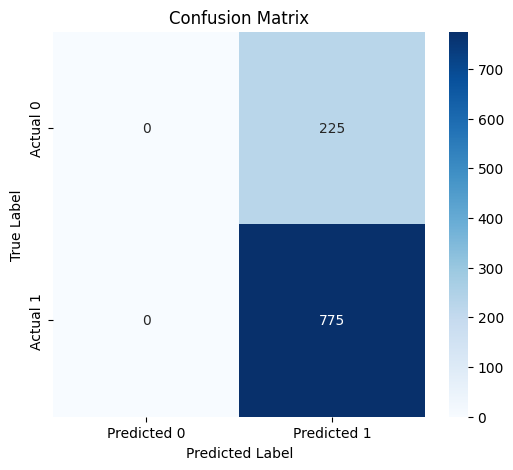

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Get class labels from y_test (assuming 0 and 1 are the only labels)
class_labels = sorted(list(y_test.unique()))

# Create a heatmap visualization of the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Predicted {label}' for label in class_labels],
            yticklabels=[f'Actual {label}' for label in class_labels])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()